DATASET SHAPE
(30220, 24)

FIRST 5 RECORDS
   EmployeeID  Age  Gender  Department        JobRole EducationLevel  \
0  EMP_114655   25  Female     Support      Team Lead            PhD   
1  EMP_115876   57    Male  Operations      Team Lead         Master   
2  EMP_104384   49    Male  Operations        Analyst            PhD   
3  EMP_107373   55    Male  Operations  Administrator        Diploma   
4  EMP_127600   51    Male          HR      Team Lead            MBA   

  MaritalStatus  YearsAtCompany  YearsInCurrentRole  MonthlyIncome  ...  \
0        Single              20                  13       80604.35  ...   
1       Married              22                  14      112208.38  ...   
2        Single               0                   0       85052.29  ...   
3        Single              20                   6      108214.61  ...   
4      Divorced              17                   5       72593.08  ...   

   JobSatisfaction  EnvironmentSatisfaction  Overtime  RemoteWork  \
0   

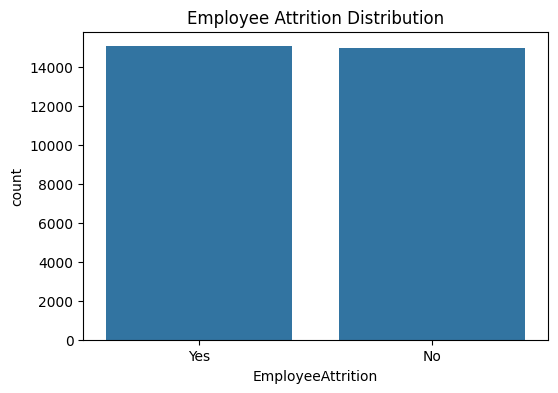

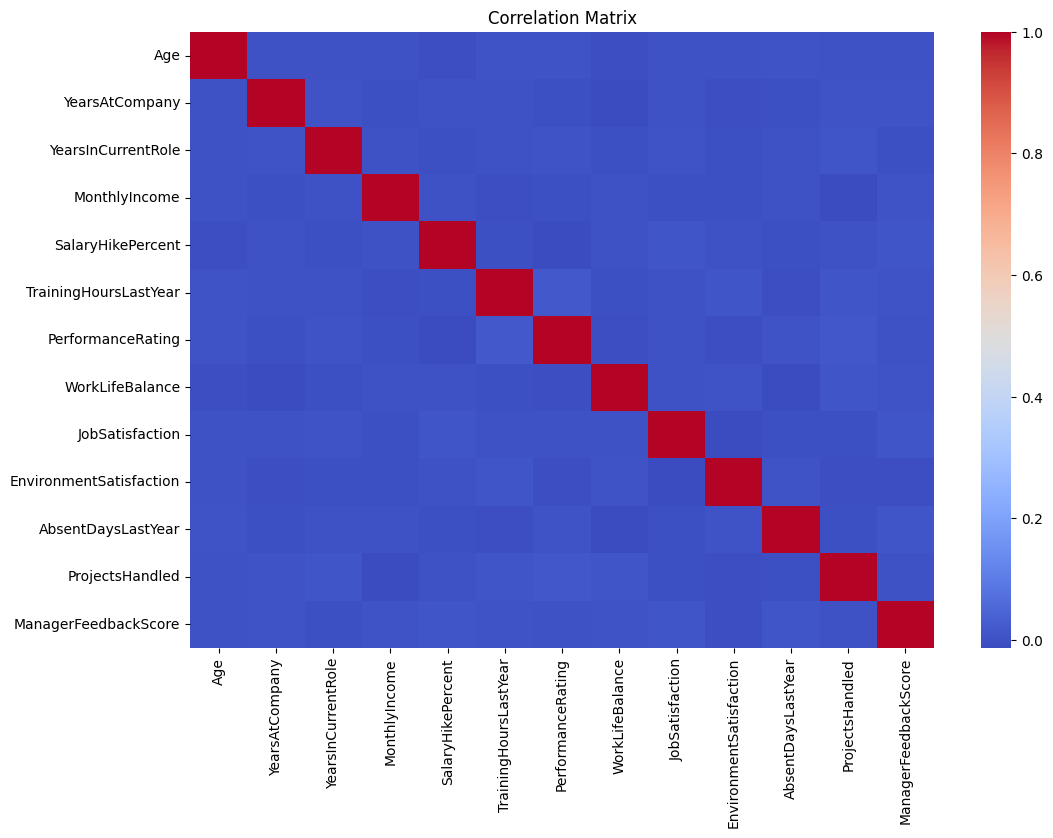

Outlier Treatment Completed

Selected Features
Index(['Age', 'YearsAtCompany', 'MonthlyIncome', 'TrainingHoursLastYear',
       'WorkLifeBalance', 'JobSatisfaction', 'EnvironmentSatisfaction',
       'AbsentDaysLastYear', 'Department_Operations', 'Department_Sales',
       'Department_Support', 'JobRole_Analyst', 'JobRole_Developer',
       'JobRole_Manager', 'JobRole_Team Lead', 'EducationLevel_Diploma',
       'MaritalStatus_Single', 'Overtime_Yes', 'BusinessTravel_Rarely',
       'PromotionLast3Years_Yes'],
      dtype='object')
(24014, 20)
(6004, 20)

KNN
              precision    recall  f1-score   support

           0       0.54      0.53      0.53      2995
           1       0.54      0.54      0.54      3009

    accuracy                           0.54      6004
   macro avg       0.54      0.54      0.54      6004
weighted avg       0.54      0.54      0.54      6004


Random Forest
              precision    recall  f1-score   support

           0       0.58      0.60    

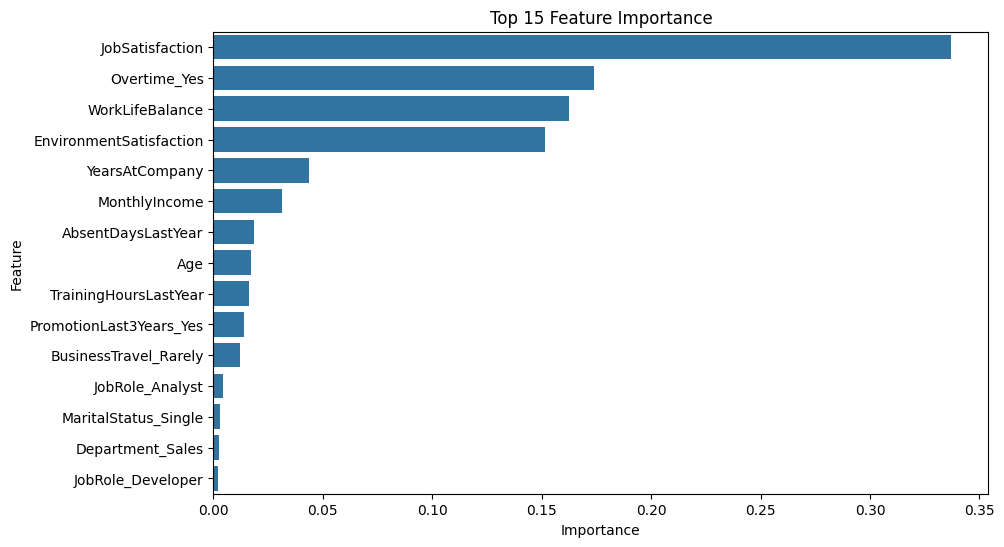

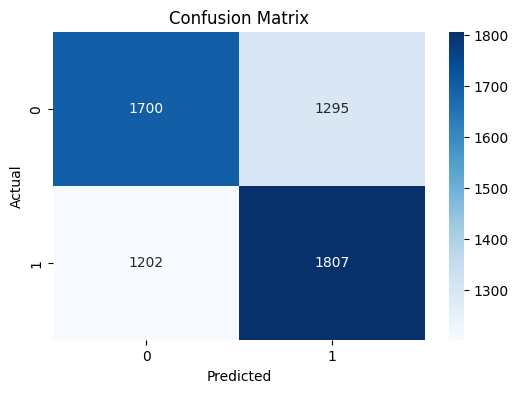


False Negatives: 1202

Business Concern:
False Negatives represent employees predicted as
LOW ATTRITION RISK but who actually leave.
These employees are the most costly mistakes.


BUSINESS INSIGHTS
JobSatisfaction
Overtime_Yes
WorkLifeBalance
EnvironmentSatisfaction
YearsAtCompany
MonthlyIncome
AbsentDaysLastYear
Age
TrainingHoursLastYear
PromotionLast3Years_Yes


Potential Attrition Drivers:

1. Job Satisfaction
   Lower satisfaction increases attrition risk.

2. Work-Life Balance
   Poor balance often leads to resignation.

3. Overtime
   Excessive overtime contributes to burnout.

4. Monthly Income
   Lower compensation may increase turnover.

5. Promotion History
   Lack of promotion impacts retention.

6. Environment Satisfaction
   Workplace dissatisfaction influences exits.

7. Manager Feedback
   Weak manager relationships can increase risk.

8. Years In Current Role
   Stagnation may lead employees to leave.

HR Recommendations:

• Monitor high-risk employees monthly.
• Impr

In [1]:
# ============================================================
# HR ATTRITION PREDICTION SYSTEM
# ============================================================

# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold
)

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.feature_selection import SelectKBest, mutual_info_classif

from sklearn.neighbors import KNeighborsClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    VotingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay
)

from sklearn.inspection import permutation_importance

import warnings
warnings.filterwarnings("ignore")

# ============================================================
# 2. LOAD DATASET
# ============================================================

df = pd.read_csv("hr_employee_attrition_dataset.csv")

print("="*60)
print("DATASET SHAPE")
print("="*60)
print(df.shape)

print("\nFIRST 5 RECORDS")
print(df.head())

print("\nCOLUMN INFO")
print(df.info())

# ============================================================
# 3. INSPECT DATASET
# ============================================================

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Rows")
print(df.duplicated().sum())

print("\nStatistical Summary")
print(df.describe(include="all"))

# ============================================================
# 4. DATA CLEANING
# ============================================================

# ------------------------------------------------------------
# A. Remove Duplicates
# ------------------------------------------------------------

df.drop_duplicates(inplace=True)

print("\nShape After Duplicate Removal:")
print(df.shape)

# ------------------------------------------------------------
# B. Standardize Text Columns
# ------------------------------------------------------------

cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .str.title()
    )

# ------------------------------------------------------------
# C. Missing Value Treatment
# ------------------------------------------------------------

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# ============================================================
# 5. EXPLORATORY DATA ANALYSIS
# ============================================================

target = "EmployeeAttrition"

print("\nTarget Distribution")
print(df[target].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x=target, data=df)
plt.title("Employee Attrition Distribution")
plt.show()

# Correlation Heatmap

plt.figure(figsize=(12,8))
sns.heatmap(
    df[numeric_cols].corr(),
    cmap='coolwarm'
)
plt.title("Correlation Matrix")
plt.show()

# ============================================================
# 6. OUTLIER DETECTION & TREATMENT
#    IQR CAPPING
# ============================================================

outlier_cols = [
    col for col in numeric_cols
    if col != "EmployeeID"
]

for col in outlier_cols:

    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])

print("Outlier Treatment Completed")

# ============================================================
# 7. ENCODE TARGET
# ============================================================

df[target] = df[target].map({
    "Yes":1,
    "No":0
})

# Remove EmployeeID
if "EmployeeID" in df.columns:
    df.drop("EmployeeID", axis=1, inplace=True)

# ============================================================
# 8. FEATURES & TARGET
# ============================================================

X = df.drop(target, axis=1)
y = df[target]

# ============================================================
# 9. IDENTIFY NUMERIC & CATEGORICAL COLUMNS
# ============================================================

num_features = X.select_dtypes(include=np.number).columns
cat_features = X.select_dtypes(include='object').columns

# ============================================================
# 10. PREPROCESSING PIPELINE
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[

        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            num_features
        ),

        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent"))
            ]),
            cat_features
        )
    ],
    remainder='drop'
)

# ============================================================
# 11. ONE-HOT ENCODING
# ============================================================

X_encoded = pd.get_dummies(
    X,
    drop_first=True
)

# ============================================================
# 12. FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_encoded)

# ============================================================
# 13. FEATURE SELECTION
# ============================================================

selector = SelectKBest(
    score_func=mutual_info_classif,
    k=min(20, X_encoded.shape[1])
)

X_selected = selector.fit_transform(
    X_scaled,
    y
)

selected_features = X_encoded.columns[
    selector.get_support()
]

print("\nSelected Features")
print(selected_features)

# ============================================================
# 14. TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

# ============================================================
# 15. BUILD BASELINE MODELS
# ============================================================

models = {

    "KNN":
        KNeighborsClassifier(),

    "Random Forest":
        RandomForestClassifier(
            random_state=42
        ),

    "AdaBoost":
        AdaBoostClassifier(
            random_state=42
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(
            random_state=42
        )
}

results = []

# ============================================================
# 16. TRAIN & EVALUATE MODELS
# ============================================================

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        prob = model.predict_proba(X_test)[:,1]
    else:
        prob = pred

    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    roc = roc_auc_score(y_test, prob)

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1,
        roc
    ])

    print("\n", "="*60)
    print(name)
    print("="*60)

    print(classification_report(y_test, pred))

# ============================================================
# 17. PERFORMANCE COMPARISON
# ============================================================

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC"
    ]
)

print("\nMODEL COMPARISON")
print(results_df.sort_values(
    by="ROC_AUC",
    ascending=False
))

# ============================================================
# 18. VOTING ENSEMBLE
# ============================================================

voting_model = VotingClassifier(

    estimators=[

        ("rf",
         RandomForestClassifier(random_state=42)
        ),

        ("ada",
         AdaBoostClassifier(random_state=42)
        ),

        ("gb",
         GradientBoostingClassifier(random_state=42)
        )

    ],

    voting='soft'
)

voting_model.fit(X_train, y_train)

voting_pred = voting_model.predict(X_test)

print("\nVoting Ensemble Performance")

print(classification_report(
    y_test,
    voting_pred
))

# ============================================================
# 19. HYPERPARAMETER TUNING
# ============================================================

param_grid = {

    'n_estimators':[100,200],
    'max_depth':[5,10,None],
    'min_samples_split':[2,5]
}

rf_grid = GridSearchCV(

    RandomForestClassifier(
        random_state=42
    ),

    param_grid=param_grid,

    cv=3,
    scoring='f1',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("\nBest Parameters")
print(rf_grid.best_params_)

best_rf = rf_grid.best_estimator_

best_pred = best_rf.predict(X_test)

print("\nTuned Random Forest")
print(classification_report(
    y_test,
    best_pred
))

# ============================================================
# 20. FEATURE IMPORTANCE
# ============================================================

importance = pd.DataFrame({

    "Feature": selected_features,
    "Importance": best_rf.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop Important Features")
print(importance.head(15))

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Feature Importance")
plt.show()

# ============================================================
# 21. ERROR ANALYSIS
# ============================================================

cm = confusion_matrix(
    y_test,
    best_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

false_negatives = np.where(
    (y_test == 1) &
    (best_pred == 0)
)[0]

print("\nFalse Negatives:", len(false_negatives))

print("""
Business Concern:
False Negatives represent employees predicted as
LOW ATTRITION RISK but who actually leave.
These employees are the most costly mistakes.
""")

# ============================================================
# 22. BUSINESS INSIGHTS
# ============================================================

print("\n" + "="*60)
print("BUSINESS INSIGHTS")
print("="*60)

top_features = importance.head(10)

for feature in top_features["Feature"]:
    print(feature)

print("""

Potential Attrition Drivers:

1. Job Satisfaction
   Lower satisfaction increases attrition risk.

2. Work-Life Balance
   Poor balance often leads to resignation.

3. Overtime
   Excessive overtime contributes to burnout.

4. Monthly Income
   Lower compensation may increase turnover.

5. Promotion History
   Lack of promotion impacts retention.

6. Environment Satisfaction
   Workplace dissatisfaction influences exits.

7. Manager Feedback
   Weak manager relationships can increase risk.

8. Years In Current Role
   Stagnation may lead employees to leave.

HR Recommendations:

• Monitor high-risk employees monthly.
• Improve promotion transparency.
• Reduce excessive overtime.
• Increase manager engagement.
• Strengthen retention programs.
• Improve employee satisfaction initiatives.
• Build attrition-risk dashboard for HR leadership.

""")